# Forget about Excel, use Pandas!

## Create your first table

Excel is a nice software to deal with daily data, i.e. to manage a budget or to analyse a few experimental dataset. Yet, when you have many data, or complex data related to molecule for instance, it can quickly becomes a nightmare... Fortunately there is also a Python library dedicated to dataset management! The library is called `pandas`, and basically allows you to perform all task you would do with Excel in an automatic and flexible way.
To be able to use `pandas`, you first need to install it: in the windows terminal, with your Python environment activated, type `conda install pandas=2.3` (be careful to install version 2.3, as the last version has some bugs...). To be able to read and write files in Excel format (which can be useful if this is the format of your experiment data or if you want to share data with people using Excel), you also need the `openpyxl` library. Install it with `conda install openpyxl`. Fially, to use the `pandas` library we need to import it as for any Python libraries:

In [1]:
import pandas as pd

Note the specific syntax here: `import pandas` (classical syntax), `as pd`. The `as pd` statement means that in the following, we are going to write `pd` as a shortcut for `pandas`: this is just a trick to save some time when writing the code (don't forget that programmers are lazy!).
Now, what can we do with `pandas` exactly? Well, we can manage data tables, just like in Excel. A table in `pandas` is implemented in a class called `Dataframe`. A `DataFrame` contains rows and columns, where each columns is also defined as a class called `pandas.Series`. To illustrate how to create a simple `Dataframe`, let's take the example of the molecule list studied in the previous section:

In [2]:
molecule_name = [ "water", "ethanol", "urea", "pentane", "acetic acid", "propanol", "formaldehyde" ]

Let's create a simple `DataFrame`, i.e. table, containing the molecule names:

In [3]:
df = pd.DataFrame(data={"molecule name" : molecule_name})

The `Dataframe` is created by calling the class name (just like for the `Molecule` class we have built in a previous section), with an argument `data`, which is a dictionnary containing the column label (`"molecule name"`) and the column values as a list (`molecule_name`). To display the resulting `Dataframe`, one can just execute a code cell with the name of the `DataFrame`, i.e. `df`:

In [4]:
df

,molecule name
0,water
1,ethanol
2,urea
3,pentane
4,acetic acid
5,propanol
6,formaldehyde


Excellent, we have just created our first `Dataframe`! Note that instead of showing the full table, which can contain thousands of lines in some instances; one can use the `head(n)` or `tail(n)` method of the `Dataframe`, which respectively prints the `n` first rows and `n` last rows of the `DataFrame`:

In [5]:
df.head(2)

,molecule name
0,water
1,ethanol


In [6]:
df.tail(2)

,molecule name
5,propanol
6,formaldehyde


Ok, this is nice but our table is a bit empty so far! What if we want to add more columns, for instance a column containing the SMILES code of the molecule? Well, there are two options. First let's us define a list of our molecules SMILES code:

In [7]:
molecule_smiles = [ "O", "CCO", "C(=O)(N)N", "CCCCC", "CC(=O)O", "CCCO", "C=O" ]

The most straightforward solution is to create a new `Dataframe` from scratch, indicating both the molecule names and smiles by extending the input dictionnary:

In [8]:
df = pd.DataFrame(data={"molecule name" : molecule_name, "SMILES" : molecule_smiles})
df

,molecule name,SMILES
0,water,O
1,ethanol,CCO
2,urea,C(=O)(N)N
3,pentane,CCCCC
4,acetic acid,CC(=O)O
5,propanol,CCCO
6,formaldehyde,C=O


But one can also start from the initial `DataFrame`, and add a new column using the `[]` operator:

In [9]:
# Create initial DataFrame
df = pd.DataFrame(data={"molecule name" : molecule_name})

# Add a column called SMILES, with values given in the list molecule_smiles
df["SMILES"] = molecule_smiles

# Show the final DataFrame
df

,molecule name,SMILES
0,water,O
1,ethanol,CCO
2,urea,C(=O)(N)N
3,pentane,CCCCC
4,acetic acid,CC(=O)O
5,propanol,CCCO
6,formaldehyde,C=O


## Combining the power of pandas and rdkit

Let us complete our table with the chemical formula, molar mass and if the molecule is an alcohol or not. To do so, let's reuse the code from the previous section. We know that for a molecule, these can be calculated from the SMILES code as followed: 

In [10]:
# Required modules for Mol creation and descriptor calculations
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Define a SMILES
smiles = "CCCO"

# Mol created from the SMILES code
mol = Chem.MolFromSmiles(smiles)
        
# Get and print the molecule raw formula
formula = rdMolDescriptors.CalcMolFormula(mol)
print(f"{smiles} formula is {formula}")

# Get and print the molar mass
mass = Descriptors.ExactMolWt(mol)
print(f"{smiles} molar mass is {mass} g/mol")

# Return all occurence of the subgroup in the molecule
alcohol_smarts = Chem.MolFromSmarts("[CX4][OX2H]")
alcohol_match = mol.GetSubstructMatches(alcohol_smarts)

# Check if the molecule is an alcohol, i.e. if it contains at least one alcohol group
is_alcohol = len(alcohol_match) > 0
print(f"Is {smiles} an alcohol: {is_alcohol}")

CCCO formula is C3H8O
CCCO molar mass is 60.057514876 g/mol
Is CCCO an alcohol: True


Now, to populate our table we would like to create a column for the formula, the molar mass and if the molecule is an alcohol by calling the above functions on every row (i.e. molecule) of our table. There is a straightforward way to do so in Python:

In [11]:
df["formula"] = df.apply(lambda row: rdMolDescriptors.CalcMolFormula( Chem.MolFromSmiles(row["SMILES"]) ), axis=1)
df

,molecule name,SMILES,formula
0,water,O,H2O
1,ethanol,CCO,C2H6O
2,urea,C(=O)(N)N,CH4N2O
3,pentane,CCCCC,C5H12
4,acetic acid,CC(=O)O,C2H4O2
5,propanol,CCCO,C3H8O
6,formaldehyde,C=O,CH2O


The syntax looks a bit heavy but is not that complicated: we create a new column called `formula`, which is the result of the application of a function (thus the `df.apply()`) to every row on the `Dataframe`, thus the `lambda row`. This function is defined as followed: For each row, we look at the SMILES column, thus the `row["SMILES"]`, and we call on it the `Chem.MolFromSmiles()` function to generate a `Mol` object, and on this `Mol` object we call the `rdMolDescriptors.CalcMolFormula()` functio to get the chemica formula. The last argument, `axis=1`, means that the function operates on every rows (`axis=0` would mean apply the function to every column).

````{admonition} Exercice
:class: tip
:label: exo_pandas_1

Complete the previous DataFrame by adding a column with the molar mass and a column indicating if the molecule is an alcohol or not.

````

````{dropdown} Solution
```{code-cell}

# Required modules for Mol creation and descriptor calculations
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Create the initial DataFrame
df = pd.DataFrame(data={"molecule name" : molecule_name, "SMILES" : molecule_smiles})

# Add chemical formula
df["formula"] = df.apply(lambda row: rdMolDescriptors.CalcMolFormula( Chem.MolFromSmiles(row["SMILES"]) ), axis=1)

# Add molar mass
df["molar mass (g/mol)"] = df.apply(lambda row: Descriptors.ExactMolWt( Chem.MolFromSmiles(row["SMILES"]) ), axis=1)

# Add if the molecule is an alcohol or not
alcohol_smarts = Chem.MolFromSmarts("[CX4][OX2H]")
df["Is alcohol?"] = df.apply(lambda row: len(Chem.MolFromSmiles(row["SMILES"]).GetSubstructMatches(alcohol_smarts)) > 0, axis=1)

# Show the DataFrame
df
```
````

Below is the final table you should obtain:

In [12]:
# Required modules for Mol creation and descriptor calculations
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Create the initial DataFrame
df = pd.DataFrame(data={"molecule name" : molecule_name, "SMILES" : molecule_smiles})

# Add chemical formula
df["formula"] = df.apply(lambda row: rdMolDescriptors.CalcMolFormula( Chem.MolFromSmiles(row["SMILES"]) ), axis=1)

# Add molar mass
df["molar mass (g/mol)"] = df.apply(lambda row: Descriptors.ExactMolWt( Chem.MolFromSmiles(row["SMILES"]) ), axis=1)

# Add if the molecule is an alcohol or not
alcohol_smarts = Chem.MolFromSmarts("[CX4][OX2H]")
df["Is alcohol?"] = df.apply(lambda row: len(Chem.MolFromSmiles(row["SMILES"]).GetSubstructMatches(alcohol_smarts)) > 0, axis=1)

# Show the DataFrame
df

,molecule name,SMILES,formula,molar mass (g/mol),Is alcohol?
0,water,O,H2O,18.010565,False
1,ethanol,CCO,C2H6O,46.041865,True
2,urea,C(=O)(N)N,CH4N2O,60.032363,False
3,pentane,CCCCC,C5H12,72.093900,False
4,acetic acid,CC(=O)O,C2H4O2,60.021129,False
5,propanol,CCCO,C3H8O,60.057515,True
6,formaldehyde,C=O,CH2O,30.010565,False


Hehe that's great no ? 😎
But the really cool stuff abourt `rdkit` is to be able to visualize the chemical structure. Can't we add that to the table?? Yes we can! This is really straightforward, as `rdkit` has a special module dedicated to show the molecular structure in `pandas`:

,molecule name,SMILES,formula,molar mass (g/mol),Is alcohol?,Molecule Structure
0,water,O,H2O,18.010565,False,
1,ethanol,CCO,C2H6O,46.041865,True,
2,urea,C(=O)(N)N,CH4N2O,60.032363,False,
3,pentane,CCCCC,C5H12,72.093900,False,
4,acetic acid,CC(=O)O,C2H4O2,60.021129,False,
5,propanol,CCCO,C3H8O,60.057515,True,
6,formaldehyde,C=O,CH2O,30.010565,False,

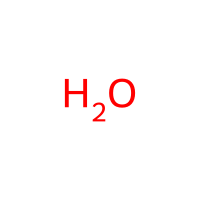
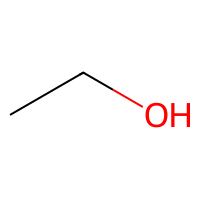
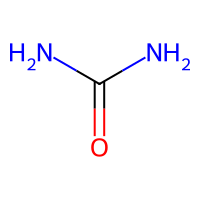
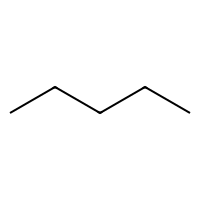
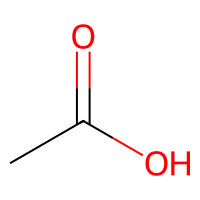
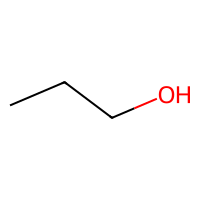
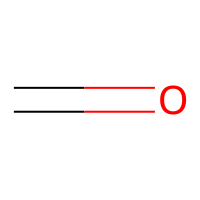

In [13]:
# Import the rdkit module that integrates molecular structures with pandas
from rdkit.Chem import PandasTools

# Add Molecular structure to the Dataframe: you need to input the Dataframe name, the column containing the SMILES code, and the name of the column that will contain the Molecular structure.
PandasTools.AddMoleculeColumnToFrame(df,'SMILES','Molecule Structure')

# This line below ensures that molecular structure are rendered in the Dataframe
PandasTools.RenderImagesInAllDataFrames()

# Show the final dataframe
df

Hehe, now the `DataFrame` looks really cool, isn't it?! 

## Save and Load data

At some point if you want to share your data or if you get data from someone else, you might want to be able to save your `DataFrame` in a file, or to load data from a file. There are several ways to do so, but the most convenient is, in my opinion, to use either *.csv* files or *.xlsx* files. *.csv* files are comma-separated files, i.e. they are just basic text files where the data (columns) are separated by a `,`. *.xlsx* files are Excel files. To see how saving/loading data works, let us first generate a basic `DataFrame` mimicking some random experimental data: for instance, a cosine output as a function of time. 

In [14]:
# Import the math library
from math import*

# Create fake data
time = [-pi + i*2*pi/1000.0 for i in range(1000)]
output = [cos(t) for t in time]

# Create a DataFrame containing these data
df = pd.DataFrame(data = { "time" : time, "output" : output })

# Show the ten first rows of the DataFrame
df.head(10)

,time,output
0,-3.141593,-1.000000
1,-3.135309,-0.999980
2,-3.129026,-0.999921
3,-3.122743,-0.999822
4,-3.116460,-0.999684
5,-3.110177,-0.999507
6,-3.103894,-0.999289
7,-3.097610,-0.999033
8,-3.091327,-0.998737
9,-3.085044,-0.998402


Now, to save the `DataFrame` to an external file we can use the following `DataFrame` methods:

In [15]:
# Saving the DataFrame to a .csv file called experimental_data.csv
df.to_csv("experimental_data.csv")

# Saving the DataFrame to a .xlsx Excel file called experimental_data.xlsx
df.to_excel("experimental_data.xlsx")

If everything ran smoothly, 2 files should have been created in the directory where your jupyter notebook is located. The *.xlsx* file can be checked-out using Excel, as shown in the Figure below:

:::{figure} images/excel_file.png
:align: center
:width: 100%

The Excel file generated from the jupyter notebook
:::

To load data in a `DataFrame` from an external file, we can use `pandas` functions. For instance, let us load the data we just saved in a new fresh `DataFrame` called `df_new`:

In [23]:
# Loading data from .csv file called experimental_data.csv
df_new = pd.read_csv("experimental_data.csv")

# Loading data from a .xlsx Excel file called experimental_data.xlsx
df_new = pd.read_excel("experimental_data.xlsx")

Of course, this new `DataFrame` contains exactly the same data as the original `df` `DataFrame`:

In [24]:
df_new.head(10)

,Unnamed: 0,time,output
0,0,-3.141593,-1.000000
1,1,-3.135309,-0.999980
2,2,-3.129026,-0.999921
3,3,-3.122743,-0.999822
4,4,-3.116460,-0.999684
5,5,-3.110177,-0.999507
6,6,-3.103894,-0.999289
7,7,-3.097610,-0.999033
8,8,-3.091327,-0.998737
9,9,-3.085044,-0.998402


## Basic DataFrame modifications

Have you noticed the weird additionnal column called `Unnamed: 0` in the `DataFrame` `df_new`? This new column has been generated by `pandas` when exporting the `DataFrame` to the Excel file, and contains the index of each row (you can actually see this column in the Figure showing the .xlsx file opened in Excel). If you want to get rid of it, one solution is to add the argument `index=False` in the `to_excel()` (or `to_csv()`) method. Another solution is to removed this column afterwards using the `drop()` method of the `Dataframe`:

In [27]:
# List all the columns of the df_new DataFrame
print(f"These are the columns in df_new: {df_new.columns}")

# Remove the unwanted column called Unnamed: 0
df_new.drop(columns=["Unnamed: 0"], inplace=True)

# Show the resulting DataFrame
df_new.head(10)

These are the columns in df_new: Index(['Unnamed: 0', 'time', 'output'], dtype='object')


,time,output
0,-3.141593,-1.000000
1,-3.135309,-0.999980
2,-3.129026,-0.999921
3,-3.122743,-0.999822
4,-3.116460,-0.999684
5,-3.110177,-0.999507
6,-3.103894,-0.999289
7,-3.097610,-0.999033
8,-3.091327,-0.998737
9,-3.085044,-0.998402


Note that when calling the `drop()` method, we need to specify the argument `inplace=True`. Otherwise, the method returns a copy of the DataFrame with the column removed, but the original `DataFrame` is left untouched.

Previously we have seen how to add new columns to a `DataFrame` containing molecular data using the `apply()` method. It is really powerful to do complex operations, but the syntax is a bit heavy. When dealing with "simple" numerical data and mathematical operations, things get much easier. For instance, to generate a new column containing the square of the output, one can proceed as follows:

In [29]:
df_new["squared output"] = df_new["output"] ** 2

df_new.head(10)

,time,output,squared output
0,-3.141593,-1.000000,1.000000
1,-3.135309,-0.999980,0.999961
2,-3.129026,-0.999921,0.999842
3,-3.122743,-0.999822,0.999645
4,-3.116460,-0.999684,0.999368
5,-3.110177,-0.999507,0.999013
6,-3.103894,-0.999289,0.998579
7,-3.097610,-0.999033,0.998067
8,-3.091327,-0.998737,0.997476
9,-3.085044,-0.998402,0.996806


We will not see here all possibilities offered by `pandas` to modify a `DataFrame` as they are pretty much infinite. Just remember that **`pandas` allow you to do any modification you could imagine, and that any modifications you would do with Excel can be done directly with `pandas`**: search the Web or ask an AI to find the function or method that would do the job. 
The last thing you need to know about `DataFrame` manipulation is that it is really easy to do modifications based on the data values. For instance, to keep only the data where the `squared output` is lower than 0.8, it takes only one single line of code:

In [32]:
# Filter the data based on the values of the column squared output
df_filtered = df_new[df_new["squared output"] <= 0.8]

# Compare the size of the original DataFrame and the filtered DataFrame
print(f"The original Dataframe contains {df_new.shape[0]} rows and {df_new.shape[1]} columns")
print(f"The filtered Dataframe contains {df_filtered.shape[0]} rows and {df_filtered.shape[1]} columns")

The original Dataframe contains 1000 rows and 3 columns
The filtered Dataframe contains 706 rows and 3 columns


As you can observe there are less rows in the filtered DataFrame which was of course the expected behavior. Yet it is not easy to really check that the filtered `DataFrame` contains only values of `"squared output"` below 0.8 as there are so many rows in the `DataFrame`. To be sure of it, one can save the `DataFrame` in an Excel file and plot the data, as shown in the Figure below.

In [33]:
# Save the filtered DataFrame
df_filtered.to_excel("filtered_data.xlsx")

:::{figure} images/excel_file_filtered.png
:align: center
:width: 100%

The filtered data plotted in Excel
:::

Perfect, the filtered data indeed as no data when the squared output ir larger than 0.8!
But wait... this section of the lecture is called *Forget about Excel, use Pandas!*, and here we need to save our data to a file and then use Excel plotting capabilities to check our data?! Are you kidding?!!🤨
No worries, jump to the next lecture section to see how to render cool plots using Python directly! 